In [11]:
!pip install thinkdsp-kim
import thinkdsp

# 2.2

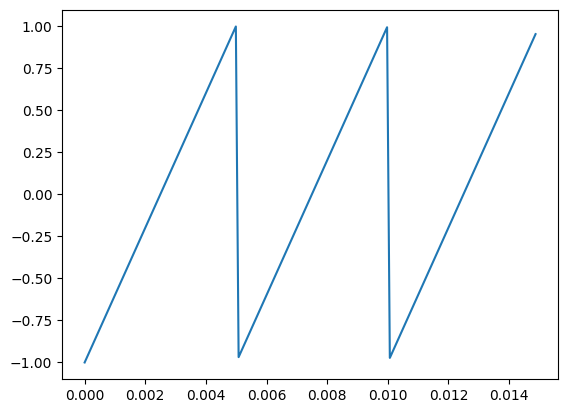

In [23]:
import numpy as np

class SawtoothSignal(thinkdsp.Sinusoid):
    def evaluate(self, ts):
        cycles = self.freq * ts + self.offset / (2 * np.pi)
        frac, _ = np.modf(cycles)
        ys = 2 * (frac - 0.5)

        ys = self.amp * ys
        return ys

signal = SawtoothSignal(freq=200, amp=1.0)

signal.plot()

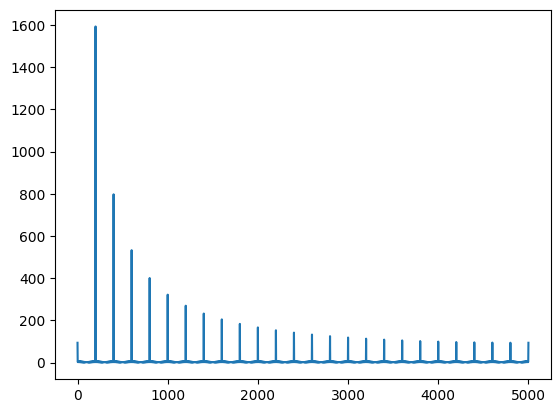

In [24]:
wave = signal.make_wave(duration=0.5, framerate=10000)
spectrum = wave.make_spectrum()

spectrum.plot()

Результат: В спектре пилообразного сигнала присутствуют как чётные, так и нечётные гармоники (200, 400, 600, 800... при частоте 200 Гц). Амплитуда гармоник убывает пропорционально 1/f (Видно, что на 200 Гц амплитуда 1600, на 400 - 800 и т.д.)

# 2.3

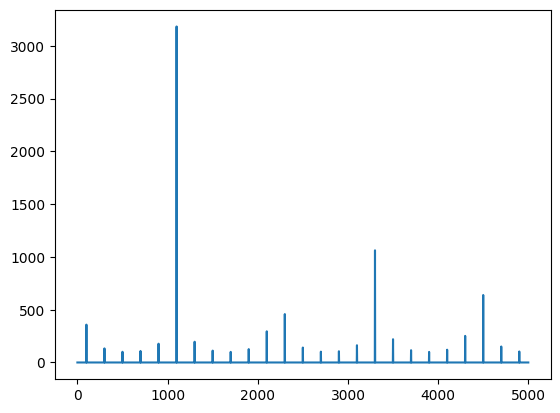

In [28]:
square = thinkdsp.SquareSignal(freq=1100)
wave = square.make_wave(duration=0.5, framerate=10000)
spectrum = wave.make_spectrum()

spectrum.plot()

Для частоты 1100 Гц видим пикки на 1100, 2200, 3300 и т.д; но, как и ожидалось, гармоники выше 5000 Гц, из-за частоты выборки 10000 Гц, "завернулись", так что видны пики на 4500, 2400 и т.д.
Создадим сигнал с той же частотой, но дискретизацией 100 000 Гц и послушаем оба (на низкой громкости)

In [33]:
square = thinkdsp.SquareSignal(freq=1100)
wave1 = square.make_wave(duration=0.5, framerate=100000)

wave1.apodize()
wave1.make_audio()

In [32]:
wave.apodize()
wave.make_audio()

Можно услышать, что сигнал при 100 000 Гц звучит намного "чище" - слышны только высокие частоты, в то время как сигнал при 10 000 Гц дискретизации содержит много низких частот

# 2.4

In [46]:
square = thinkdsp.SquareSignal(freq=1100)
wave = square.make_wave(duration=0.5, framerate=10000)
spectrum = wave.make_spectrum()

print(spectrum.fs[0], spectrum.fs[1], spectrum.fs[2], spectrum.fs[4], spectrum.fs[5])
print(spectrum.hs[0])

0.0 2.0 4.0 8.0 10.0
0j


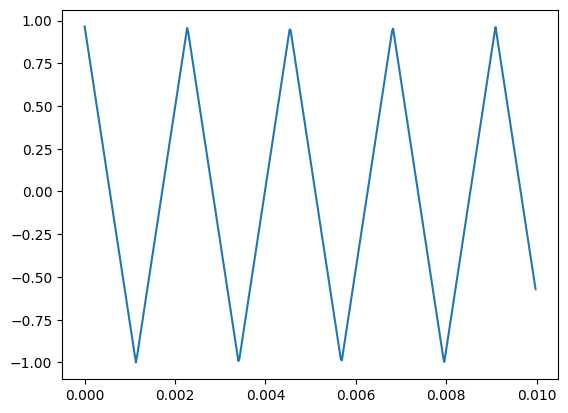

In [55]:
import numpy as np

triangle = thinkdsp.TriangleSignal(freq=440)
wave = triangle.make_wave(duration=0.01, framerate=44100)
wave.plot()

In [65]:
spectrum = wave.make_spectrum()
print("hs[0] =", spectrum.hs[0])
print("Амплитуда:", abs(spectrum.hs[0]))
print("Фаза (рад):", np.angle(spectrum.hs[0]))

hs[0] = (1.6542323066914832e-14+0j)
Амплитуда: 1.6542323066914832e-14
Фаза (рад): 0.0


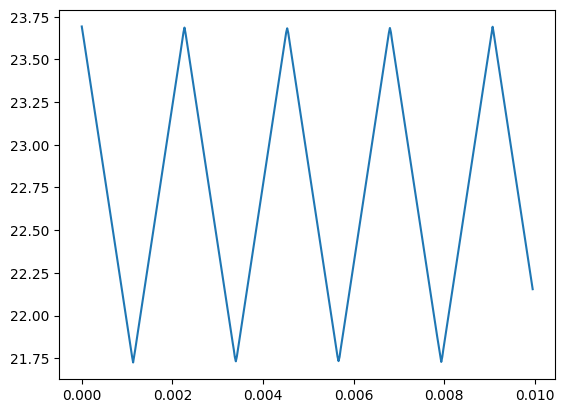

In [67]:
spectrum.hs[0] = 10000
new_wave = spectrum.make_wave()
new_wave.plot()

Сигнал сдвинулся относительно оси абсцисс на 0.25 вверх, из-за чего пики теперь на 1.25 и -0.75. Т.е, параметр регулирует постоянное смещение.

# 2.5

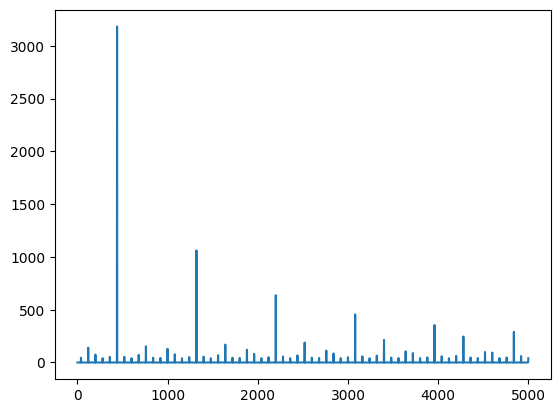

In [77]:
import numpy as np

def divide_by_frequency(spectrum):
    hs_copy = spectrum.hs.copy()
    fs = spectrum.fs
    hs_copy[0] = 0
    hs_copy[1:] /= fs[1:]
    # создаём новый спектр
    new_spec = thinkdsp.Spectrum(hs_copy, fs, spectrum.framerate)
    return new_spec

square = thinkdsp.SquareSignal(freq=440)
wave = square.make_wave(duration=0.5, framerate=10000)
orig_spectrum = wave.make_spectrum()

new_spectrum = divide_by_frequency(orig_spectrum)
new_wave = new_spectrum.make_wave()

orig_spectrum.plot(label='Исходный')
wave.apodize()
wave.make_audio()


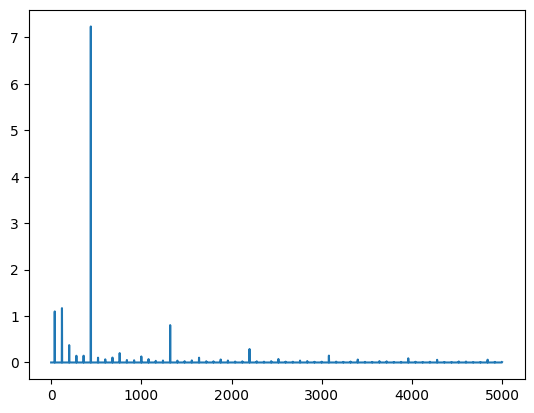

In [78]:
new_spectrum.plot(label='После деления')
new_wave.apodize()
new_wave.make_audio()

При делении на частоту получаем, что высокочастотные гармоники стали гораздо меньше, чем низкочастотные. Влияние на звук соответствующее.

# 2.6

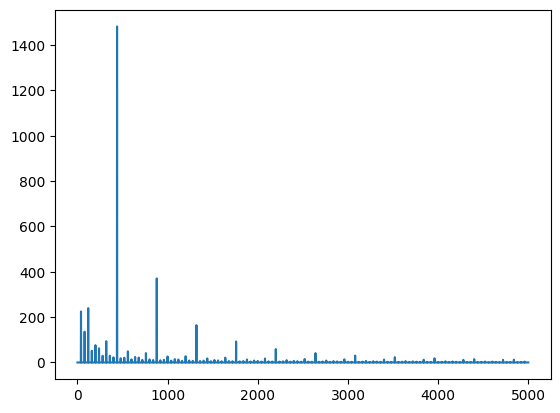

In [88]:
saw = thinkdsp.SawtoothSignal(freq=440)
wave_saw = saw.make_wave(duration=0.5, framerate=10000)
# Интегрируем через спектр
spectrum_saw = wave_saw.make_spectrum()
spectrum_saw.hs[1:] /= (2 * np.pi * 1j * spectrum_saw.fs[1:])  # деление на f
integrated_wave = spectrum_saw.make_wave()
integrated_wave.normalize()
spectrum_int = integrated_wave.make_spectrum()
spectrum_int.plot()

"Интегрируем" пилообразный сигнал, поделим его спектр на частоту, тем самым сделав уменьшение не на 1/f, а на 1/f^2